# Interaction NN: Breaking the Linearity Barrier

This notebook investigates whether the **Interaction NN** — a summary-statistics neural network that exploits second-order interaction statistics $\Gamma_{ij} = \mathbb{E}[x_i x_j y]$ — can break the linearity barrier that prevents standard summary-statistics methods from outperforming linear PRS on nonlinear phenotypes.

**Methods compared (5 total):**
1. **Linear PRS** — optimal linear weights $\Sigma^{-1} \Sigma_\beta$
2. **Gaussian NN** — summary-stat NN under Gaussian genotype assumption
3. **Edgeworth NN** — summary-stat NN with higher-order cumulant corrections
4. **Interaction NN** — summary-stat NN using $\Gamma_{ij}$ to capture nonlinear signal
5. **Oracle NN** — individual-level NN trained on raw genotype data (upper bound)

**Central hypothesis:** Under a nonlinear DGP with $y = \beta^{*\top} x + \gamma \cdot \text{ReLU}(w^{*\top} x) + \varepsilon$, methods 1–3 only access $\Sigma_\beta = \mathbb{E}[xy]$, which captures only the linear component. The Interaction NN accesses $\Gamma$, which encodes information about the nonlinear component, so it should track closer to the Oracle NN as the nonlinear fraction increases.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from ssnn.simulation import (
    SimulationScenario,
    run_scenario,
    run_single_rep,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

METHOD_COLORS = {
    "Linear PRS": "#4C72B0",
    "Gaussian NN": "#DD8452",
    "Edgeworth NN": "#C44E52",
    "Interaction NN": "#8172B3",
    "Oracle NN": "#937860",
}
METHOD_ORDER = ["Linear PRS", "Gaussian NN", "Edgeworth NN", "Interaction NN", "Oracle NN"]

## 1. Sanity Check: Single Replicate on Nonlinear DGP

Run one replicate with `dgp_type="nonlinear"` and `nonlinear_frac=0.25` to verify the pipeline works and check whether the Interaction NN already shows an advantage over Gaussian NN. With 25% of genetic variance from the ReLU component, the linear methods should miss a meaningful portion of the signal.

In [2]:
sanity_scenario = SimulationScenario(
    p=30, m=5, n_train=5000, n_test=2000,
    maf_spectrum="mixed", ld_decay=0.5, heritability=0.5,
    sparsity=0.3, dgp_type="nonlinear", nonlinear_frac=0.25,
    activation="relu",
    sumstat_max_iters=3000, interaction_max_iters=3000, oracle_max_iters=5000,
)

rng = np.random.default_rng(42)
sanity_results = run_single_rep(sanity_scenario, rng)

print("--- Sanity Check: Nonlinear DGP (1 rep) ---")
print(f"{'Method':<18s} {'R²':>8s} {'cos(w, β*)':>12s}")
print("-" * 42)
for sr in sanity_results:
    print(f"{sr.method:<18s} {sr.r2:8.4f} {sr.weight_cosine:12.4f}")

gauss_r2 = next(sr.r2 for sr in sanity_results if sr.method == "Gaussian NN")
inter_r2 = next(sr.r2 for sr in sanity_results if sr.method == "Interaction NN")
print(f"\nInteraction NN {'>' if inter_r2 > gauss_r2 else '<='} Gaussian NN: "
      f"{inter_r2:.4f} vs {gauss_r2:.4f} (Δ = {inter_r2 - gauss_r2:+.4f})")

--- Sanity Check: Nonlinear DGP (1 rep) ---
Method                   R²   cos(w, β*)
------------------------------------------
Linear PRS           0.3004       0.6862
Gaussian NN          0.3005       0.6862
Edgeworth NN         0.2875       0.6884
Interaction NN       0.3406       0.7260
Oracle NN            0.5300       0.9264

Interaction NN > Gaussian NN: 0.3406 vs 0.3005 (Δ = +0.0401)


## 2. Main Comparison: Nonlinear DGP with Multiple Replicates

Run 10 replicates of the nonlinear DGP scenario and display a grouped bar chart of mean $R^2$ by method, with standard-error bars. This gives a stable picture of how each method performs when 25% of genetic variance is nonlinear.

In [3]:
main_scenario = SimulationScenario(
    p=30, m=5, n_train=5000, n_test=2000,
    maf_spectrum="mixed", ld_decay=0.5, heritability=0.5,
    sparsity=0.3, dgp_type="nonlinear", nonlinear_frac=0.25,
    activation="relu",
    sumstat_max_iters=3000, interaction_max_iters=3000, oracle_max_iters=5000,
)

main_results = run_scenario(main_scenario, n_reps=10, seed=42, verbose=True)

  Replicate 1/10 ...


  Replicate 2/10 ...


  Replicate 3/10 ...


  Replicate 4/10 ...


  Replicate 5/10 ...


  Replicate 6/10 ...


  Replicate 7/10 ...


  Replicate 8/10 ...


  Replicate 9/10 ...


  Replicate 10/10 ...


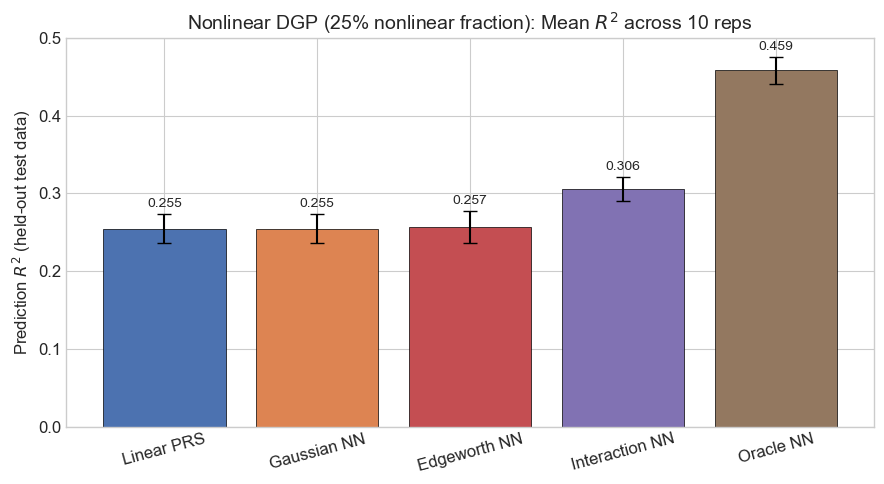

Method              Mean R²       SE
------------------------------------
Linear PRS           0.2548   0.0190
Gaussian NN          0.2548   0.0190
Edgeworth NN         0.2571   0.0206
Interaction NN       0.3058   0.0150
Oracle NN            0.4589   0.0174


In [4]:
r2_by_method = defaultdict(list)
for row in main_results:
    r2_by_method[row["method"]].append(row["r2"])

means = [np.mean(r2_by_method[m]) for m in METHOD_ORDER]
ses = [np.std(r2_by_method[m]) / np.sqrt(len(r2_by_method[m])) for m in METHOD_ORDER]
colors = [METHOD_COLORS[m] for m in METHOD_ORDER]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(METHOD_ORDER, means, yerr=ses, capsize=5,
              color=colors, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Prediction $R^2$ (held-out test data)")
ax.set_title("Nonlinear DGP (25% nonlinear fraction): Mean $R^2$ across 10 reps")
ax.set_ylim(bottom=0)
for bar, mean_val, se_val in zip(bars, means, ses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + se_val + 0.005,
            f"{mean_val:.3f}", ha="center", va="bottom", fontsize=10)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

print(f"{'Method':<18s} {'Mean R²':>8s} {'SE':>8s}")
print("-" * 36)
for m in METHOD_ORDER:
    vals = r2_by_method[m]
    print(f"{m:<18s} {np.mean(vals):8.4f} {np.std(vals)/np.sqrt(len(vals)):8.4f}")

## 3. Nonlinear Fraction Sweep

This is the key experiment. We vary `nonlinear_frac` from 0 (purely linear DGP) to 0.75 (heavily nonlinear). The theory predicts:

- **Linear PRS, Gaussian NN, Edgeworth NN** should all decline together as nonlinear fraction grows, because they only access $\Sigma_\beta = \mathbb{E}[xy]$ — which captures only the linear component of the phenotype.
- **Interaction NN** should degrade more slowly, tracking closer to the Oracle NN, because $\Gamma_{ij} = \mathbb{E}[x_i x_j y]$ encodes information about the nonlinear term.
- **Oracle NN** should be relatively robust since it trains directly on individual-level data.

In [5]:
nonlinear_fracs = [0.0, 0.10, 0.25, 0.50, 0.75]

nf_results = {}
for nf in nonlinear_fracs:
    print(f"\n=== nonlinear_frac = {nf:.2f} ===")
    scenario = SimulationScenario(
        p=30, m=5, n_train=5000, n_test=2000,
        maf_spectrum="mixed", ld_decay=0.5, heritability=0.5,
        sparsity=0.3, dgp_type="nonlinear", nonlinear_frac=nf,
        activation="relu",
        sumstat_max_iters=2000, interaction_max_iters=2000, oracle_max_iters=3000,
    )
    nf_results[nf] = run_scenario(scenario, n_reps=5, seed=200, verbose=True)


=== nonlinear_frac = 0.00 ===
  Replicate 1/5 ...


  Replicate 2/5 ...


  Replicate 3/5 ...


  Replicate 4/5 ...


  Replicate 5/5 ...


...


=== nonlinear_frac = 0.75 ===
  Replicate 1/5 ...


  Replicate 2/5 ...


  Replicate 3/5 ...


  Replicate 4/5 ...


  Replicate 5/5 ...


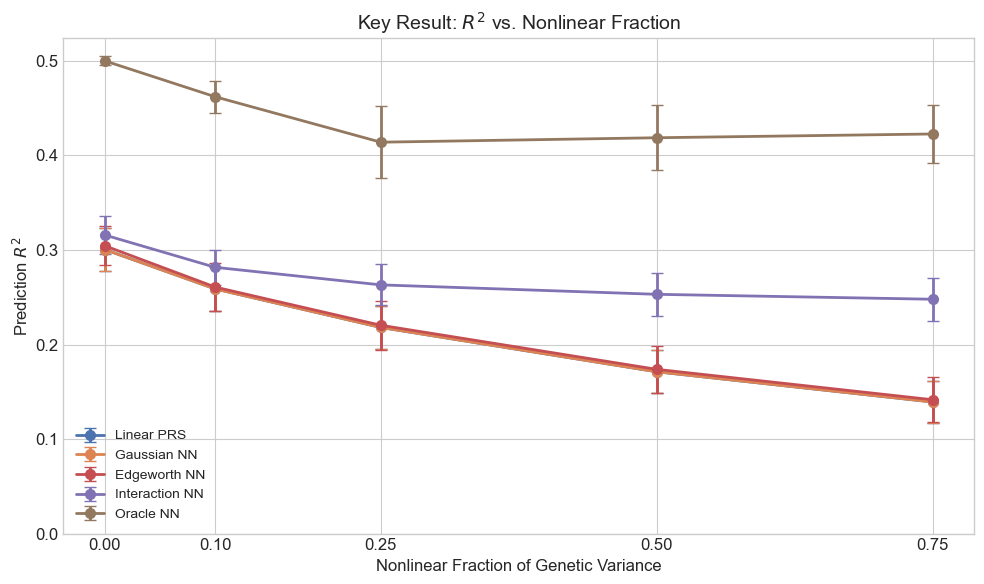

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for method in METHOD_ORDER:
    method_means = []
    method_ses = []
    for nf in nonlinear_fracs:
        vals = [r["r2"] for r in nf_results[nf] if r["method"] == method]
        method_means.append(np.mean(vals))
        method_ses.append(np.std(vals) / np.sqrt(len(vals)))
    ax.errorbar(nonlinear_fracs, method_means, yerr=method_ses,
                marker="o", label=method, color=METHOD_COLORS[method],
                capsize=4, linewidth=2, markersize=7)

ax.set_xlabel("Nonlinear Fraction of Genetic Variance")
ax.set_ylabel("Prediction $R^2$")
ax.set_title("Key Result: $R^2$ vs. Nonlinear Fraction")
ax.legend(fontsize=10, loc="best")
ax.set_ylim(bottom=0)
ax.set_xticks(nonlinear_fracs)
plt.tight_layout()
plt.show()

## 4. Sample Size Sweep

Fix `nonlinear_frac=0.25` and vary `n_train`. This tests whether larger samples help the Interaction NN disproportionately, since the estimation quality of $\Gamma_{ij} = \frac{1}{n} \sum_i x_i x_j y_i$ improves with $n$ (it is a third-moment quantity with higher variance than $\Sigma_\beta$).

In [7]:
n_train_values = [1000, 3000, 5000, 10000]

ns_results = {}
for n_train in n_train_values:
    print(f"\n=== n_train = {n_train} ===")
    scenario = SimulationScenario(
        p=30, m=5, n_train=n_train, n_test=2000,
        maf_spectrum="mixed", ld_decay=0.5, heritability=0.5,
        sparsity=0.3, dgp_type="nonlinear", nonlinear_frac=0.25,
        activation="relu",
        sumstat_max_iters=2000, interaction_max_iters=2000, oracle_max_iters=3000,
    )
    ns_results[n_train] = run_scenario(scenario, n_reps=5, seed=300, verbose=True)


=== n_train = 1000 ===
  Replicate 1/5 ...


  Replicate 2/5 ...


  Replicate 3/5 ...


  Replicate 4/5 ...


  Replicate 5/5 ...


...


=== n_train = 10000 ===
  Replicate 1/5 ...


  Replicate 2/5 ...


  Replicate 3/5 ...


  Replicate 4/5 ...


  Replicate 5/5 ...


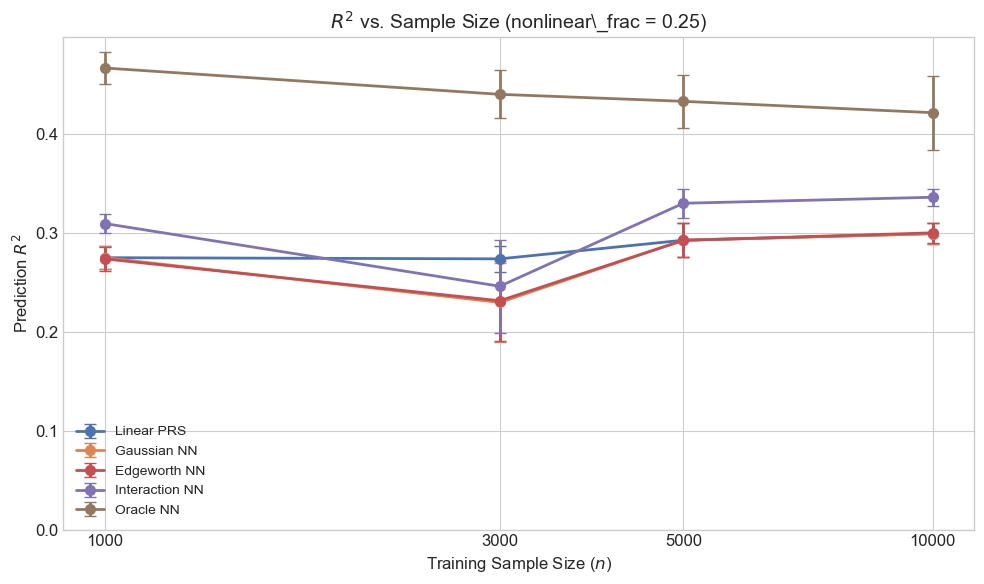

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

for method in METHOD_ORDER:
    method_means = []
    method_ses = []
    for n_train in n_train_values:
        vals = [r["r2"] for r in ns_results[n_train] if r["method"] == method]
        method_means.append(np.mean(vals))
        method_ses.append(np.std(vals) / np.sqrt(len(vals)))
    ax.errorbar(n_train_values, method_means, yerr=method_ses,
                marker="o", label=method, color=METHOD_COLORS[method],
                capsize=4, linewidth=2, markersize=7)

ax.set_xlabel("Training Sample Size ($n$)")
ax.set_ylabel("Prediction $R^2$")
ax.set_title("$R^2$ vs. Sample Size (nonlinear\\_frac = 0.25)")
ax.legend(fontsize=10, loc="best")
ax.set_ylim(bottom=0)
ax.set_xscale("log")
ax.set_xticks(n_train_values)
ax.set_xticklabels([str(n) for n in n_train_values])
plt.tight_layout()
plt.show()

## 5. Summary Table

Aggregate mean $R^2$ and standard deviation across all sweeps.

In [9]:
summary_rows = []

for nf in nonlinear_fracs:
    for method in METHOD_ORDER:
        vals = [r["r2"] for r in nf_results[nf] if r["method"] == method]
        summary_rows.append({
            "sweep": "NL Frac", "param": f"{nf:.2f}",
            "method": method, "mean_r2": np.mean(vals), "std_r2": np.std(vals),
        })

for n_train in n_train_values:
    for method in METHOD_ORDER:
        vals = [r["r2"] for r in ns_results[n_train] if r["method"] == method]
        summary_rows.append({
            "sweep": "n_train", "param": str(n_train),
            "method": method, "mean_r2": np.mean(vals), "std_r2": np.std(vals),
        })

print(f"{'Sweep':<10s} {'Param':<8s} {'Method':<18s} {'Mean R²':>8s} {'Std R²':>8s}")
print("=" * 56)
prev_key = None
for row in summary_rows:
    key = (row["sweep"], row["param"])
    if prev_key is not None and key != prev_key:
        print("-" * 56)
    print(f"{row['sweep']:<10s} {row['param']:<8s} {row['method']:<18s} "
          f"{row['mean_r2']:8.4f} {row['std_r2']:8.4f}")
    prev_key = key

Sweep      Param    Method              Mean R²   Std R²
NL Frac    0.00     Linear PRS           0.3005   0.0507
NL Frac    0.00     Gaussian NN          0.3004   0.0507
NL Frac    0.00     Edgeworth NN         0.3045   0.0465
NL Frac    0.00     Interaction NN       0.3158   0.0450
NL Frac    0.00     Oracle NN            0.5001   0.0107
--------------------------------------------------------
NL Frac    0.10     Linear PRS           0.2588   0.0516
NL Frac    0.10     Gaussian NN          0.2588   0.0516
NL Frac    0.10     Edgeworth NN         0.2608   0.0574
NL Frac    0.10     Interaction NN       0.2817   0.0410
NL Frac    0.10     Oracle NN            0.4621   0.0379
--------------------------------------------------------
NL Frac    0.25     Linear PRS           0.2181   0.0514
NL Frac    0.25     Gaussian NN          0.2181   0.0514
NL Frac    0.25     Edgeworth NN         0.2204   0.0580
NL Frac    0.25     Interaction NN       0.2631   0.0485
NL Frac    0.25     Oracle NN  

## Interpretation

**What to look for:**

- **Nonlinear fraction sweep (Section 3):** The key figure. If the Interaction NN breaks the linearity barrier, its line should stay elevated while the linear/Gaussian/Edgeworth lines decline together as `nonlinear_frac` increases. The gap between Interaction NN and the linear methods should widen monotonically.

- **Sample size sweep (Section 4):** The Interaction NN uses $\Gamma$, a third-moment statistic with higher variance than $\Sigma_\beta$. If sample size is the bottleneck, we should see Interaction NN improving faster than Gaussian/Edgeworth NN as $n$ grows.

- **If the Interaction NN does NOT clearly outperform:** Possible explanations include (a) the Gamma estimate is too noisy for the given $p$ and $n$, (b) the interaction optimizer gets stuck in a poor local minimum, or (c) the current parameterization doesn't fully exploit the Gamma signal. All are valid research findings.